In [135]:
# Sales Data Analysis Project

# Goal: Identify trends, seasonality, and revenue growth
# Dataset: Superstore sales data

In [136]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
# import csv file
df = pd.read_csv(r"C:\Users\Admin\Downloads\Sales-Data-Analysis-main\Sample - Superstore.csv", encoding='ISO-8859-1')



In [138]:
df.shape

(19991, 21)

In [139]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0,41.91
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0,219.58
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0,6.87
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.2,2.52


## Data Cleaning

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Row ID         19991 non-null  object
 1   Order ID       19989 non-null  object
 2   Order Date     19989 non-null  object
 3   Ship Date      19989 non-null  object
 4   Ship Mode      19989 non-null  object
 5   Customer ID    19989 non-null  object
 6   Customer Name  19989 non-null  object
 7   Segment        19989 non-null  object
 8   Country        19989 non-null  object
 9   City           19989 non-null  object
 10  State          19989 non-null  object
 11  Postal Code    19989 non-null  object
 12  Region         19989 non-null  object
 13  Product ID     19989 non-null  object
 14  Category       19989 non-null  object
 15  Sub-Category   19989 non-null  object
 16  Product Name   19989 non-null  object
 17  Sales          19989 non-null  object
 18  Quantity       19989 non-n

In [141]:
#check for null values
pd.isnull(df).sum()

Row ID           0
Order ID         2
Order Date       2
Ship Date        2
Ship Mode        2
Customer ID      2
Customer Name    2
Segment          2
Country          2
City             2
State            2
Postal Code      2
Region           2
Product ID       2
Category         2
Sub-Category     2
Product Name     2
Sales            2
Quantity         2
Discount         2
Profit           2
dtype: int64

In [142]:
# remove unnecessary column
df.drop(['Row ID'], axis=1, inplace=True)

In [143]:
#converting in actual date
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [144]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [145]:
# removing duplicate
df.drop_duplicates(inplace=True)

DERIVING NEW COLUMNS

In [172]:
df['Year'] = df['Order Date'].dt.year

In [147]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [148]:

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 10

In [149]:

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df['Sales Per Unit'] = df['Sales'] / df['Quantity']


OVERALL SALES TREND

In [150]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

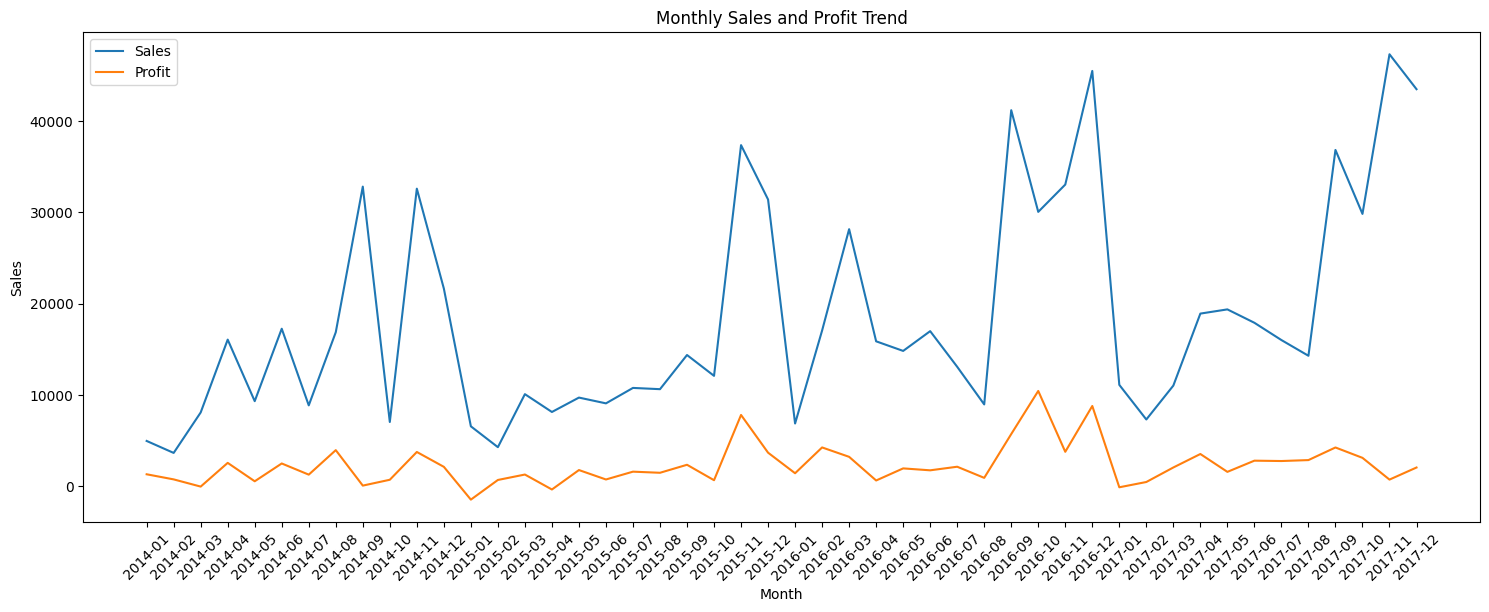

In [151]:
plt.figure(figsize=(15,6))
sns.lineplot(x='Month', y='Sales', data=monthly_sales, label='Sales')
sns.lineplot(x='Month', y='Profit', data=monthly_sales, label='Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Monthly Sales and Profit Trend')
plt.legend()
plt.show()

CATEGORY WISE ANALYSIS

In [152]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

In [153]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1000x500 with 0 Axes>

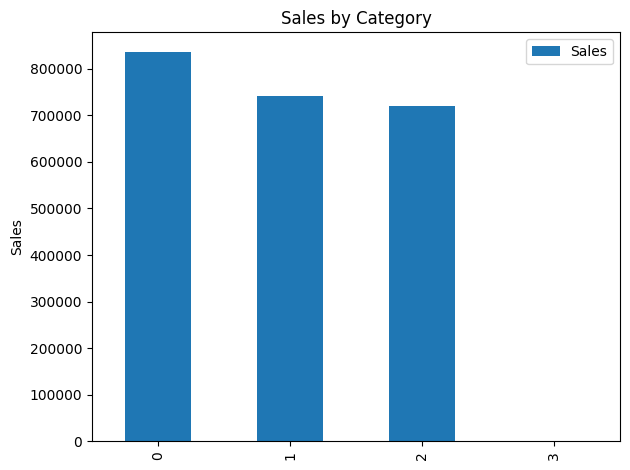

In [173]:
plt.figure(figsize=(10,5))
category_sales.plot(kind='bar', title='Sales by Category')
# sns.barplot(y = 'Sales', data = category_sales)
plt.ylabel('Sales')
plt.tight_layout()
plt.show

<Figure size 1200x500 with 0 Axes>

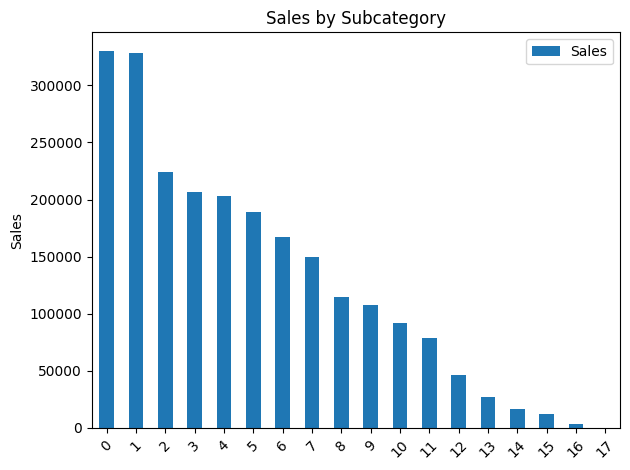

In [155]:
plt.figure(figsize=(12,5))
subcategory_sales.plot(kind='bar', title='Sales by Subcategory')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

REGION WISE SALES

In [156]:
region_sales = df.groupby('Region')['Sales'].sum().sort_index(ascending=False)

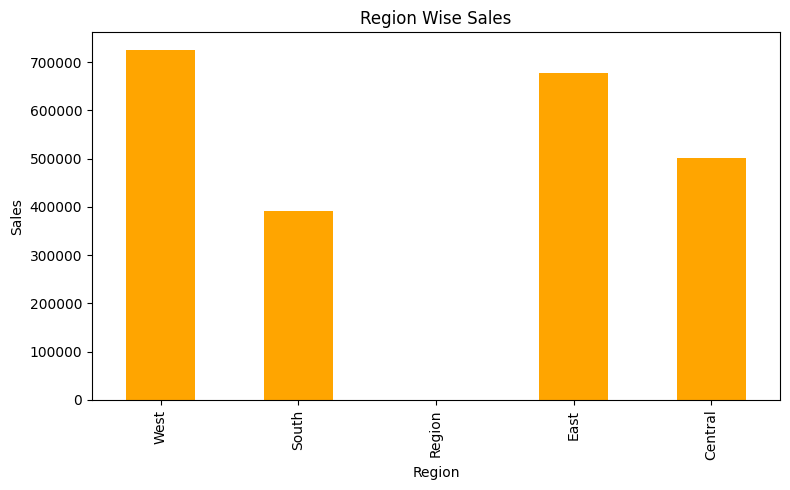

In [157]:
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='orange', title='Region Wise Sales')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

TOP PRODUCTS AND CUSTOMERS

In [158]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [159]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

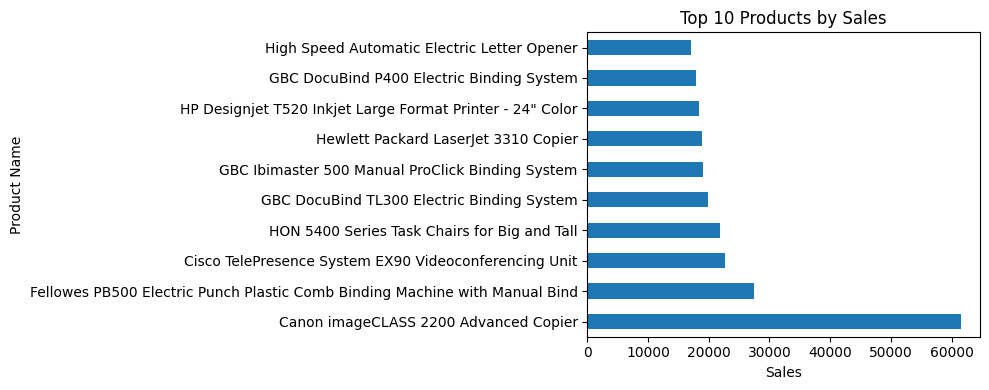

In [160]:
plt.figure(figsize=(10,4))
top_products.plot(kind='barh', title='Top 10 Products by Sales')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

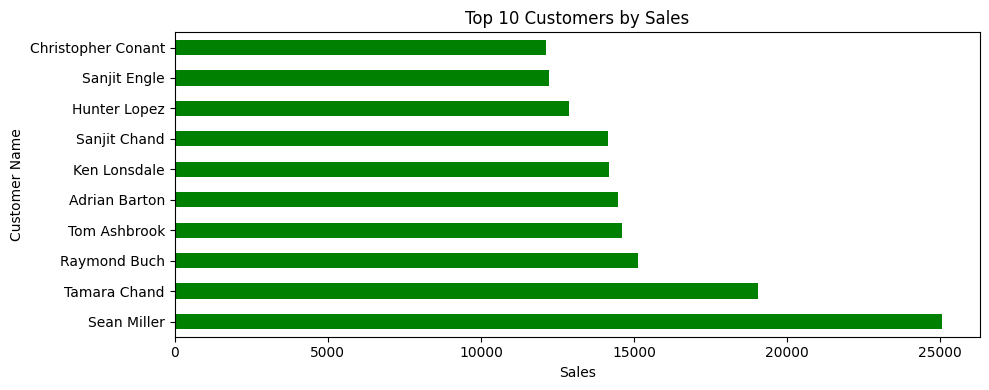

In [161]:
plt.figure(figsize=(10,4))
top_customers.plot(kind='barh', color='green', title='Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

DISCOUNT VS PROFIT

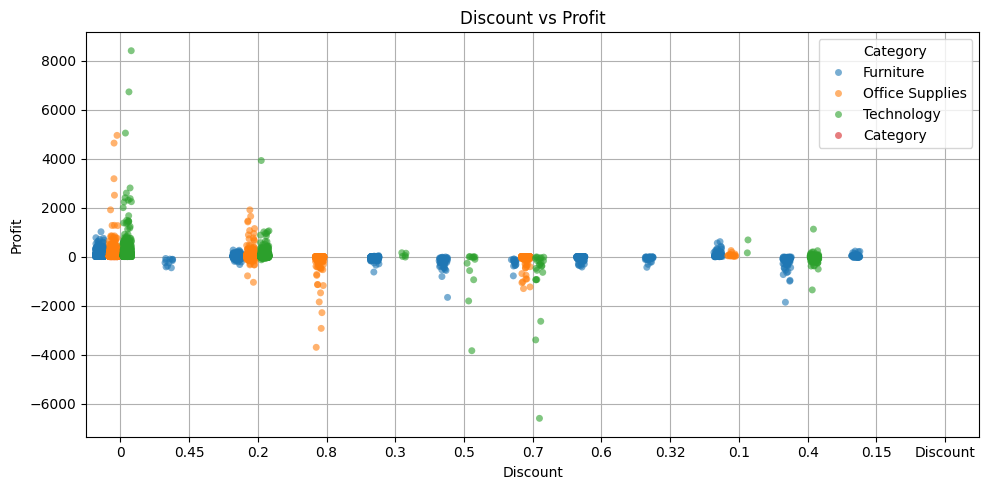

In [162]:
plt.figure(figsize=(10,5))
sns.stripplot(x='Discount', y='Profit', hue='Category', data=df, dodge=True, jitter=0.25, alpha=0.6)
plt.title('Discount vs Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

In [171]:
df.to_csv('Cleaned_Superstore_Sales.csv', index=False)